# Lesson 8 Assignment

##### Importing required datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

##### Importing Dataset and assigning dataset into a DataFrame

In [2]:
data = pd.read_csv("breastcancer.csv")
data.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


#### <span style = "color: red"> 1. Perform Data exploratory analysis on the data. </span>

##### As part of exploratory analysis on the data, we will check for the following:
- descriptive statistics of the dataset
- checking for any null values in a column
- duplicate rows

In [3]:
data.describe(include = 'all')

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [4]:
data.isnull().sum() # no null val

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

##### The above row proves that the data has no null values

In [5]:
data.duplicated().sum() # no duplicates

0

##### This proves that the dataset has no duplicate rows

##### Comparison of the classification of data (how many healthy controls (1) and how many patients (2)

In [6]:
data.Classification.value_counts()

2    64
1    52
Name: Classification, dtype: int64

##### Importing additional scikit learn modules for:
* dataset split
* performance evaluation metrics
* preprocessing of data
* determining feature importance

In [7]:
from sklearn.model_selection import train_test_split
from sklearn import metrics 
from sklearn import preprocessing
from sklearn.inspection import permutation_importance

##### As the dataset column values are of different magnitude of ranges, we will standardize each column data using a MinMaxScaler function run on the column to preserve any outliers in each column data and still keep the complete data normalized.

In [8]:
scaler = preprocessing.MinMaxScaler()

##### We will run the scaler on all the columns except the Classification column to keep the classification values intact.

In [9]:
data[data.columns[data.columns != "Classification"]] = scaler.fit_transform(data[data.columns[data.columns != "Classification"]])

data

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,0.369231,0.253850,0.070922,0.004908,0.000000,0.052299,0.221152,0.060665,0.224659,1
1,0.907692,0.114826,0.226950,0.012190,0.009742,0.052726,0.103707,0.010826,0.255926,1
2,0.892308,0.235278,0.219858,0.036874,0.022058,0.158526,0.571021,0.076906,0.307912,1
3,0.676923,0.148328,0.120567,0.014171,0.005911,0.064811,0.151538,0.121131,0.533934,1
4,0.953846,0.135640,0.226950,0.019936,0.013748,0.027782,0.086940,0.093375,0.440565,1
...,...,...,...,...,...,...,...,...,...,...
111,0.323077,0.419620,0.226950,0.016028,0.011727,0.585897,0.287049,0.098238,0.134568,2
112,0.584615,0.419125,0.283688,0.037446,0.026441,0.094674,0.543206,0.052098,0.172043,2
113,0.630769,0.676934,0.262411,0.058863,0.036757,0.664996,0.573988,0.090252,0.162294,2
114,0.738462,0.357271,0.156028,0.006925,0.004189,0.240191,0.882091,0.000761,0.209741,2


##### Next, we will run a correlation function on the dataset to see how different features correlate with Classification column.

In [10]:
data.corr() # correlation between features

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
Age,1.000000,0.008530,0.230106,0.032495,0.127033,0.102626,-0.219813,0.002742,0.013462,-0.043555
BMI,0.008530,1.000000,0.138845,0.145295,0.114480,0.569593,-0.302735,0.195350,0.224038,-0.132586
Glucose,0.230106,0.138845,1.000000,0.504653,0.696212,0.305080,-0.122121,0.291327,0.264879,0.384315
Insulin,0.032495,0.145295,0.504653,1.000000,0.932198,0.301462,-0.031296,0.146731,0.174356,0.276804
HOMA,0.127033,0.114480,0.696212,0.932198,1.000000,0.327210,-0.056337,0.231101,0.259529,0.284012
Leptin,0.102626,0.569593,0.305080,0.301462,0.327210,1.000000,-0.095389,0.256234,0.014009,-0.001078
Adiponectin,-0.219813,-0.302735,-0.122121,-0.031296,-0.056337,-0.095389,1.000000,-0.252363,-0.200694,-0.019490
Resistin,0.002742,0.195350,0.291327,0.146731,0.231101,0.256234,-0.252363,1.000000,0.366474,0.227310
MCP.1,0.013462,0.224038,0.264879,0.174356,0.259529,0.014009,-0.200694,0.366474,1.000000,0.091381
Classification,-0.043555,-0.132586,0.384315,0.276804,0.284012,-0.001078,-0.019490,0.227310,0.091381,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

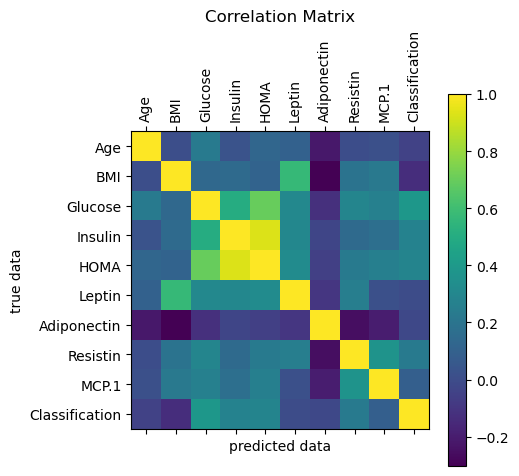

In [11]:
plt.matshow(data.corr())
plt.title("Correlation Matrix")
plt.colorbar()
plt.xlabel("predicted data")
plt.ylabel("true data")
plt.xticks(range(10), list(data.columns), rotation = "vertical")
plt.yticks(range(10), list(data.columns))
plt.show

##### <span style="color:blue">Observation:</span>
From the correlation matrix, we can say that the following features are ranked as the most important features for the classification of an individual:
1. **Glucose**
2. **HOMA**
3. **Insulin**

#### <span style = "color: red"> 2. Use 30% of data as the test set and build a Logistic regression model to predict Labels variable. </span>

##### We will start off by importing the necessary library for Logistic Regression

In [12]:
from sklearn import linear_model

##### Splitting the dataset in a 70-30 split (70% training, 30% testing)

In [13]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((81, 9), (35, 9), (81,), (35,))

In [14]:
lr = linear_model.LogisticRegression()

In [15]:
lr_model = lr.fit(X_train, y_train)
y_train_predict = lr.predict(X_train)
y_test_predict = lr.predict(X_test)

##### Accuracy score for the Logistic Regression model

In [16]:
metrics.accuracy_score(y_train, y_train_predict)

0.691358024691358

In [17]:
metrics.accuracy_score(y_test, y_test_predict)

0.6857142857142857

##### Confusion matrix for the dataset given on a Logistic Regression model

In [18]:
cm_train = metrics.confusion_matrix(y_train, y_train_predict)
cm_train

array([[14, 21],
       [ 4, 42]], dtype=int64)

In [19]:
cm_test = metrics.confusion_matrix(y_test, y_test_predict)
cm_test

array([[ 9,  8],
       [ 3, 15]], dtype=int64)

##### Finding out the coefficients of the Logistic Regression to determine the most important feature for the dataset

In [20]:
lr.coef_

array([[-0.47391739, -0.63629047,  1.4715949 ,  0.96337857,  0.7524771 ,
        -0.18973549, -0.17455044,  0.48249796,  0.20031623]])

##### <span style="color: blue"> Observation: </span>
We can see that the 3rd feature (**Glucose**) has the highest coefficient, followed by **Insulin** and this is an added proof regarding the most important features for this dataset.

##### We will now additionally determine the contribution of each feature to the model's statistical performance, thereby finding the most important feature for the Logistic Regression model. This will be determined using permutation_importance function

In [21]:
result = permutation_importance (lr_model, X_test, y_test, n_repeats = 10, random_state = 42)

In [22]:
pd.DataFrame({"features": X_train.columns, "mean": result.importances_mean, "stddev": result.importances_std})

,features,mean,stddev
0,Age,-0.020000,0.051190
1,BMI,0.077143,0.051190
2,Glucose,0.068571,0.034286
3,Insulin,0.020000,0.042474
4,HOMA,0.028571,0.033806
5,Leptin,0.037143,0.018295
6,Adiponectin,0.002857,0.023733
7,Resistin,0.031429,0.039279
8,MCP.1,0.005714,0.024908


##### <span style="color: blue"> Observation </span>
Any feature that has the highest mean with a comparatively low standard deviation is the most important feature. From the above table, we can conclude that:
* __Glucose__ is the most important feature for this model (with almost the highest mean and close to the lowest variance
* __BMI__ is the next most important feature for this model (with the highest mean)

In [23]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           1       0.75      0.53      0.62        17
           2       0.65      0.83      0.73        18

    accuracy                           0.69        35
   macro avg       0.70      0.68      0.68        35
weighted avg       0.70      0.69      0.68        35



Text(0.5, 0, 'Predicted label')

<Figure size 640x480 with 0 Axes>

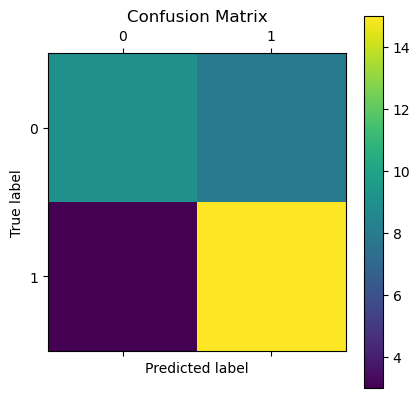

In [24]:
plt.figure()
plt.matshow(cm_test)
plt.title("Confusion Matrix")
plt.colorbar()
plt.ylabel("True label")
plt.xlabel("Predicted label")

##### From the confusion matrix, we can observe that the model creates more False Negatives than False Positives

#### <span style = "color: red"> 3. Build the Naïve Bayes model to predict Labels variable. </span>

##### Importing the required library

In [25]:
from sklearn.naive_bayes import GaussianNB

In [26]:
NB = GaussianNB()
NB_model = NB.fit(X_train, y_train)
y_train_predict = NB.predict(X_train)
y_test_predict = NB.predict(X_test)

##### Accuracy metrics score and Confusion Matrix for the Naive Bayes model

In [27]:
metrics.accuracy_score(y_train, y_train_predict)

0.6049382716049383

In [28]:
metrics.accuracy_score(y_test, y_test_predict)

0.6571428571428571

In [29]:
cm_train = metrics.confusion_matrix(y_train, y_train_predict)
cm_train

array([[31,  4],
       [28, 18]], dtype=int64)

In [30]:
cm_test = metrics.confusion_matrix(y_test, y_test_predict)
cm_test

array([[15,  2],
       [10,  8]], dtype=int64)

##### We can determine the mean and standard deviation of each feature using the mean (NB.theta_) and variance (NB.var_) associated with the Naive Bayes estimator.

In [31]:
NB_means = pd.DataFrame(index = X_train.columns)
for i in range(NB.theta_.shape[0]):
    NB_means[i] = NB.theta_[i].tolist()

NB_means.columns = y_train.unique()
NB_means

,1,2
Age,0.543736,0.511371
BMI,0.490902,0.432477
Glucose,0.206890,0.324391
Insulin,0.089708,0.201833
HOMA,0.049196,0.142996
Leptin,0.272434,0.266057
Adiponectin,0.226368,0.219067
Resistin,0.120465,0.160920
MCP.1,0.265315,0.297616


In [32]:
NB_std = pd.DataFrame(index = X_train.columns)
for i in range(NB.var_.shape[0]):
    NB_std[i] = NB.var_[i].tolist()

NB_std.columns = y_train.unique()
NB_std

,1,2
Age,0.084490,0.044808
BMI,0.066254,0.050406
Glucose,0.004523,0.029590
Insulin,0.009319,0.056083
HOMA,0.002981,0.042142
Leptin,0.053355,0.047765
Adiponectin,0.046382,0.022797
Resistin,0.027614,0.019681
MCP.1,0.027121,0.043906


##### Similar to Logistic Regression, we will run the permutation_importance function on the Naive Bayes model to determine which feature contributes the most to the model's performance and hence is the most important feature.

In [33]:
result = permutation_importance (NB_model, X_test, y_test, n_repeats = 10, random_state = 42)

In [34]:
pd.DataFrame({"features": X_train.columns, "mean": result.importances_mean, "stddev": result.importances_std})

,features,mean,stddev
0,Age,-0.008571,0.013093
1,BMI,-0.005714,0.011429
2,Glucose,0.040000,0.060204
3,Insulin,-0.005714,0.056856
4,HOMA,-0.011429,0.048149
5,Leptin,-0.002857,0.008571
6,Adiponectin,-0.017143,0.026186
7,Resistin,-0.014286,0.014286
8,MCP.1,-0.002857,0.026954


##### <span style = "color:blue" > Observation </span>
From the above table, we can conclude that **Glucose** is the most important feature for the model because it has the highest mean and a low standard deviation.

In [35]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           1       0.60      0.88      0.71        17
           2       0.80      0.44      0.57        18

    accuracy                           0.66        35
   macro avg       0.70      0.66      0.64        35
weighted avg       0.70      0.66      0.64        35



Text(0.5, 0, 'Predicted label')

<Figure size 640x480 with 0 Axes>

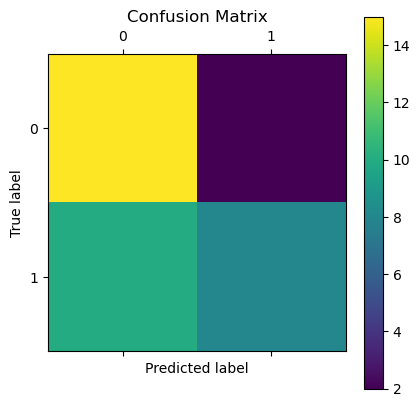

In [36]:
plt.figure()
plt.matshow(cm_test)
plt.title("Confusion Matrix")
plt.colorbar()
plt.ylabel("True label")
plt.xlabel("Predicted label")

##### From the confusion matrix, we can conclude that this model has more False Positives than False Negatives

#### <span style = "color:red"> 4. Build the Decision tree model to predict Labels variable </span>

##### Importing the required libraries

In [37]:
from sklearn import tree

In [38]:
DT = tree.DecisionTreeClassifier(max_depth = 10, min_samples_split = 5)
DT.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=5)

In [39]:
y_pred = DT.predict(X_test)

##### Accuracy score and the in-built feature importance function to determine the most important feature

In [40]:
metrics.accuracy_score(y_test, y_pred)

0.8

In [41]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.81      0.76      0.79        17
           2       0.79      0.83      0.81        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35



In [42]:
feat_imp = pd.DataFrame({"variable": data.columns[:-1], "importance": DT.feature_importances_})
feat_imp

,variable,importance
0,Age,0.116292
1,BMI,0.150526
2,Glucose,0.359399
3,Insulin,0.000000
4,HOMA,0.060736
5,Leptin,0.069276
6,Adiponectin,0.138301
7,Resistin,0.046488
8,MCP.1,0.058981


##### <span style = "color: blue">Observation</span>
We can conclude that **Glucose** is the most important feature for the Decision Tree modeler. 

##### Additionally, here is a graph of the Decision Tree Model created

In [43]:
from graphviz import Source

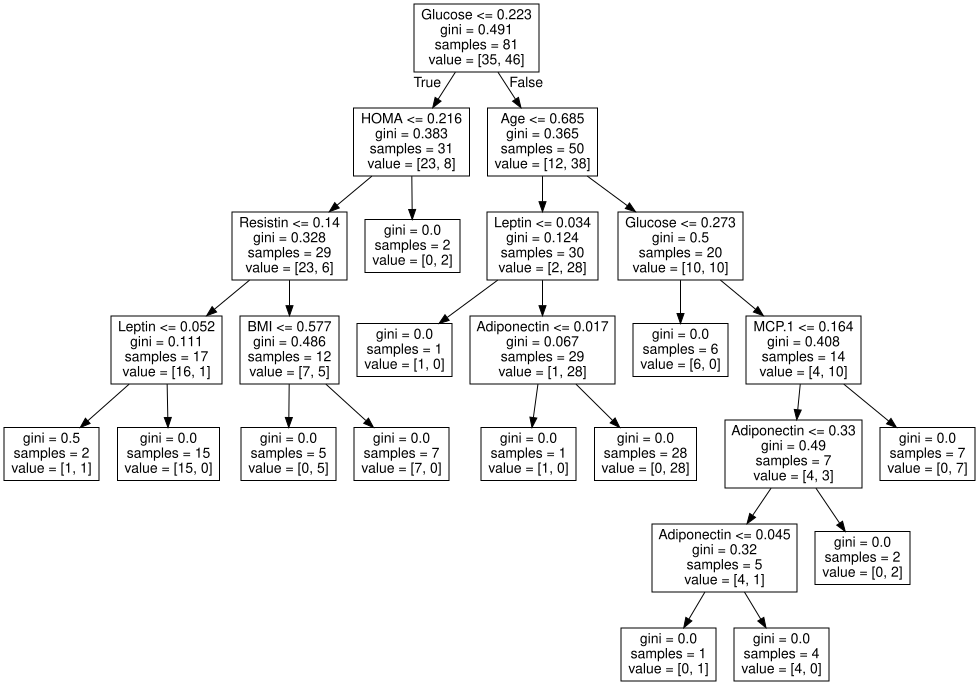

In [44]:
dot_data = tree.export_graphviz(DT, out_file = None, feature_names = X_train.columns)
Source(dot_data)

#### <span style = "color:red">5. Build Neural network model to predict Labels variable.</span>

##### Importing required library

In [45]:
from sklearn.neural_network import MLPClassifier

In [46]:
NN = MLPClassifier(solver = 'lbfgs', alpha = 1e-5, hidden_layer_sizes = (9, 9, 9), random_state = 1)
NN_model = NN.fit(X_train, y_train)

In [47]:
y_pred = NN.predict(X_test)

##### Calculating the accuracy score, generating the classification report and fetching the feature importance

In [48]:
metrics.accuracy_score(y_pred, y_test)

0.8

In [49]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.88      0.81        17
           2       0.87      0.72      0.79        18

    accuracy                           0.80        35
   macro avg       0.81      0.80      0.80        35
weighted avg       0.81      0.80      0.80        35



In [50]:
result = permutation_importance (NN_model, X_train, y_train, n_repeats = 10, random_state = 42)

In [51]:
pd.DataFrame({"features": X_train.columns, "mean": result.importances_mean, "stddev": result.importances_std})

,features,mean,stddev
0,Age,0.287654,0.024722
1,BMI,0.154321,0.038747
2,Glucose,0.286420,0.049011
3,Insulin,0.100000,0.022393
4,HOMA,0.074074,0.022085
5,Leptin,0.166667,0.041039
6,Adiponectin,0.191358,0.026043
7,Resistin,0.175309,0.036540
8,MCP.1,0.172840,0.038252


##### <span style = "color: blue"> Observation </span>
From the above table, we can see that **Age** followed by **Glucose** are the most important feature among others for a Neural Network model running on this dataset

#### <span style = "color:red"> 6. Which model is the best? Which variable is the most important one?

##### <span style = "color: blue">Evaluating Models:</span>
For a model determining breast cancer, **False Positives** for a person in classification category **1 (Healthy Controls)**, might lead to emotional turmoil and the person has to go for an additional testing to be certain about it and get relieved. But all the cases in classification category **2 (Patients)**, where the model predicts a **False Negative**, are cases which can aggravate the conditions of the patient due to lack of timely treatment. Hence, in my opinion, any model with the highest **Recall** for classification category "**2 (Patients)**" would be the best model for this problem scenario. Looking at the **Recall** values for all the 4 models, we can see the following 2 models have the highest recall values:
1. Decision Tree Classifier (0.83)
2. Logistic Regression Classifier (0.83) 

Now to determine the better model among these 2, we will go to the **Precision** of these models for Classification Category **1 (Healthy Controls)**. A high precision model would reduce the rate of **False Positives** and prevent Patients being wrongly classified as Healthy Controls. From the 2 models, we find the following Precision scores:
1. Decision Tree Classifier (0.81)
2. Logistic Regression Classifer (0.75)

We can also see that the **F-score** for Decision Tree Classifier is better for both the classification categories as compared to Logistic Regression Classifier's numbers.

Therefore, the final answer to the best model for determining breast cancer is - **Decision Tree Classifier** model.

<span style = "color: blue">**Most Important Variable**:</span><br><br>
From all the different evaluation done throughout this exercise - starting with correlation coefficient matrix to evaluating feature importance for each model, I have determined that **Glucose is the most imporant variable** for Cancer detection, because it has been ranked highest or in the top 2 variables in all the tests.


### End of Assignment